In [3]:
#%pip install pandas
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 10.2 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 12.3 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.5 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 8.2 MB/s eta 0:00:01
   ------------------ --------------------- 3.4/7.2 MB 8.7 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 10.8 MB/s eta 0:00:01
   -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
# Celda 1 – Verificación de entorno

import sys

print(f"Python: {sys.version}")

for paquete in ["sklearn", "pandas", "matplotlib", "numpy"]:
    try:
        modulo = __import__(paquete)
        print(f"{paquete}: {modulo.__version__} ✓")
    except ImportError:
        print(f"{paquete} no instalado – ejecuta: pip install {paquete}")

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
sklearn: 1.9.0 ✓
pandas: 3.0.5 ✓
matplotlib: 3.11.1 ✓
numpy: 2.5.1 ✓


In [2]:
# Celda 2 – Cargar y explorar el dataset

from sklearn.datasets import fetch_california_housing
import pandas as pd

datos = fetch_california_housing(as_frame=True)
df = datos.frame

print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
print(f"\nVariables: {list(datos.feature_names)}")
print("Variable objetivo: MedHouseVal (valor medio de vivienda, cientos de miles USD)\n")

df.describe()

Filas: 20640 | Columnas: 9

Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variable objetivo: MedHouseVal (valor medio de vivienda, cientos de miles USD)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# Celda 3 – Correlación de cada variable con el precio

correlaciones = df.corr()["MedHouseVal"].sort_values(ascending=False)
print (correlaciones);

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [3]:
# Celda 4 — Partición
from sklearn.model_selection import train_test_split
 
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
 
print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")# Celda 4 — Partición
from sklearn.model_selection import train_test_split

Train: 16512 filas | Test: 4128 filas


In [4]:
# Celda 5 – Entrenamiento

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.Series(
    modelo.coef_,
    index=X.columns
).sort_values(
    key=abs,
    ascending=False
)

print("Coeficientes del modelo (ordenados por magnitud):")
print(coeficientes)
print(f"\nIntercepto: {modelo.intercept_:.4f}")

Coeficientes del modelo (ordenados por magnitud):
AveBedrms     0.783145
MedInc        0.448675
Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
HouseAge      0.009724
AveOccup     -0.003526
Population   -0.000002
dtype: float64

Intercepto: -37.0233


In [5]:
# Celda 6 — Métricas en train y test
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
 
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)
 
print(f"{'Conjunto':<8} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 34)
for nombre, y_real, y_pred in [("Train", y_train, pred_train), ("Test", y_test,
pred_test)]:
 r2 = r2_score(y_real, y_pred)
 rmse = np.sqrt(mean_squared_error(y_real, y_pred))
 mae = mean_absolute_error(y_real, y_pred)
 print(f"{nombre:<8} {r2:>8.3f} {rmse:>8.3f} {mae:>8.3f}")

Conjunto       R²     RMSE      MAE
----------------------------------
Train       0.613    0.720    0.529
Test        0.576    0.746    0.533


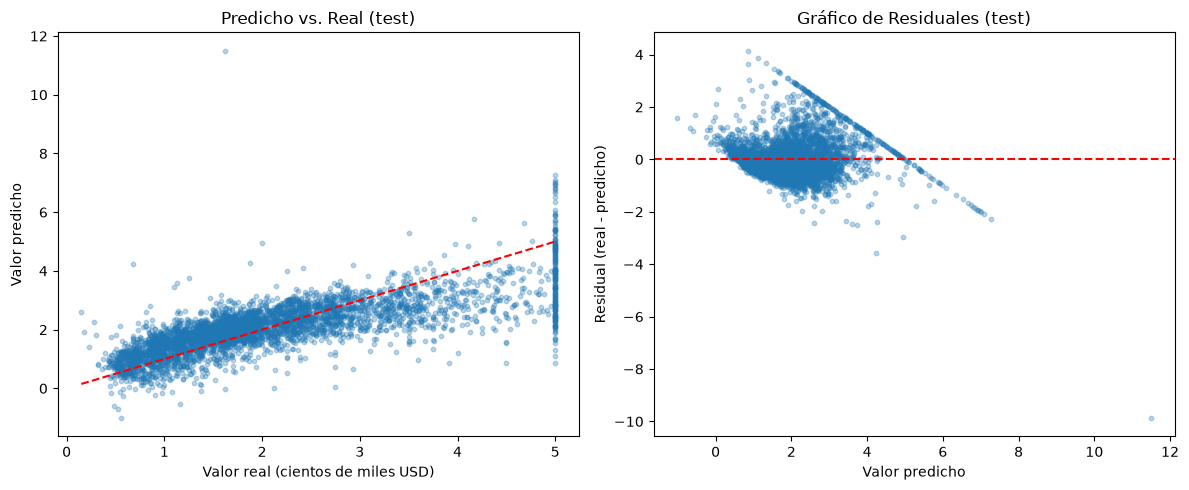

In [6]:
 # Celda 7 — Visualización: predicho vs. real
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(y_test, pred_test, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Valor real (cientos de miles USD)")
axes[0].set_ylabel("Valor predicho")
axes[0].set_title("Predicho vs. Real (test)")
 
residuales = y_test - pred_test
axes[1].scatter(pred_test, residuales, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Valor predicho")
axes[1].set_ylabel("Residual (real - predicho)")
axes[1].set_title("Gráfico de Residuales (test)")
 
plt.tight_layout()
plt.show()

In [7]:
# BONO — ¿Cuánto R² se pierde usando solo las 2 variables más correlacionadas?
 
variables_reducidas = ["MedInc", "AveRooms"] # las 2 con mayor |correlación| según
#Celda 3
 
modelo_reducido = LinearRegression()
modelo_reducido.fit(X_train[variables_reducidas], y_train)
 
pred_test_reducido = modelo_reducido.predict(X_test[variables_reducidas])
r2_reducido = r2_score(y_test, pred_test_reducido)
 
print(f"R² con 8 variables: {r2_score(y_test, pred_test):.3f}")
print(f"R² con 2 variables: {r2_reducido:.3f}")
print(f"Diferencia: {r2_score(y_test, pred_test) - r2_reducido:.3f}")

R² con 8 variables: 0.576
R² con 2 variables: 0.464
Diferencia: 0.112
